## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Загрузка данных

In [2]:
df = pd.read_csv('../data/cnt_events_transformed_v2_daily.csv')

df.head()

,dt,cnt_id,cycle_id,event,location_name,end_location_name,cnt_type,days_until_free,event_code,event_age_days,prev_event_duration_days
0,2006-02-05,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,56,1,0,0
1,2006-02-06,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,55,1,1,0
2,2006-02-07,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,54,1,2,0
3,2006-02-08,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,53,1,3,0
4,2006-02-09,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,52,1,4,0


In [3]:
df.loc[lambda d: (d["cycle_id"]=="STNU2517447_cycle_3")]

,dt,cnt_id,cycle_id,event,location_name,end_location_name,cnt_type,days_until_free,event_code,event_age_days,prev_event_duration_days
22028,2006-04-02,STNU2517447,STNU2517447_cycle_3,Передан_на_погрузку,Владивосток,Санкт-Петербург,40,35,1,0,0
22029,2006-04-03,STNU2517447,STNU2517447_cycle_3,Передан_на_погрузку,Владивосток,Санкт-Петербург,40,34,1,1,0
22030,2006-04-04,STNU2517447,STNU2517447_cycle_3,Передан_на_погрузку,Владивосток,Санкт-Петербург,40,33,1,2,0
22031,2006-04-05,STNU2517447,STNU2517447_cycle_3,Передан_на_погрузку,Владивосток,Санкт-Петербург,40,32,1,3,0
22032,2006-04-06,STNU2517447,STNU2517447_cycle_3,Передан_на_погрузку,Владивосток,Санкт-Петербург,40,31,1,4,0
22033,2006-04-07,STNU2517447,STNU2517447_cycle_3,Передан_на_погрузку,Владивосток,Санкт-Петербург,40,30,1,5,0
22034,2006-04-08,STNU2517447,STNU2517447_cycle_3,Передан_на_погрузку,Владивосток,Санкт-Петербург,40,29,1,6,0
22035,2006-04-09,STNU2517447,STNU2517447_cycle_3,Передан_на_погрузку,Владивосток,Санкт-Петербург,40,28,1,7,0
22036,2006-04-10,STNU2517447,STNU2517447_cycle_3,Передан_на_погрузку,Владивосток,Санкт-Петербург,40,27,1,8,0
22037,2006-04-11,STNU2517447,STNU2517447_cycle_3,Прибыл_груженый,Владивосток,Санкт-Петербург,40,26,2,0,9


<Axes: xlabel='event', ylabel='days_until_free'>

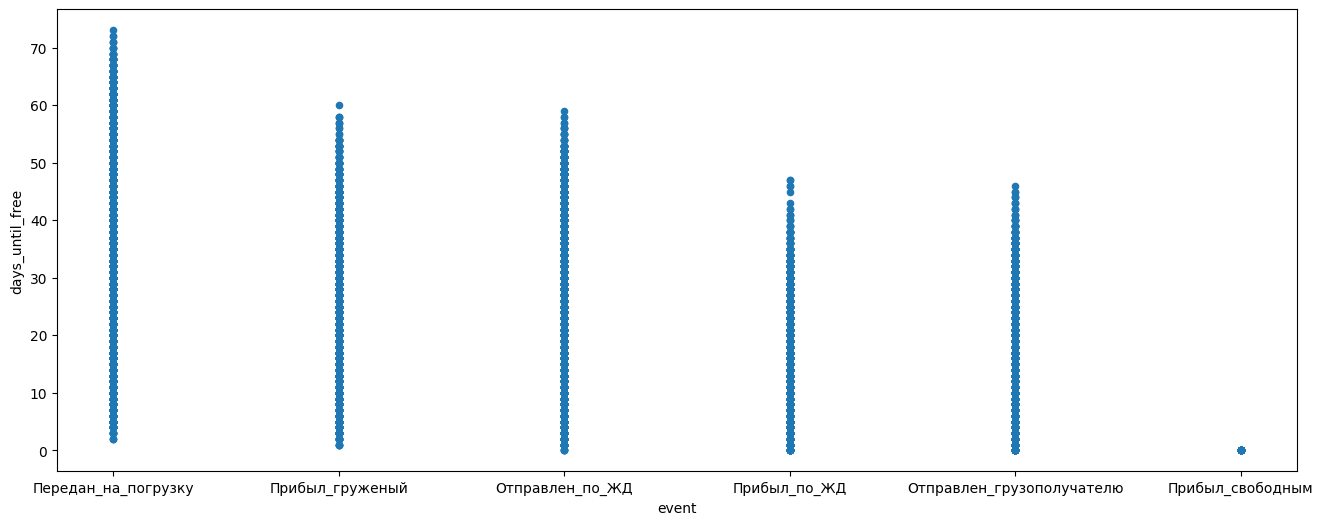

In [4]:
df.plot.scatter(x="event", y="days_until_free", figsize=(16, 6) )


## EDA

Просматриваем информацию о данных

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44853 entries, 0 to 44852
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   dt                        44853 non-null  object
 1   cnt_id                    44853 non-null  object
 2   cycle_id                  44853 non-null  object
 3   event                     44853 non-null  object
 4   location_name             44853 non-null  object
 5   end_location_name         44853 non-null  object
 6   cnt_type                  44853 non-null  int64 
 7   days_until_free           44853 non-null  int64 
 8   event_code                44853 non-null  int64 
 9   event_age_days            44853 non-null  int64 
 10  prev_event_duration_days  44853 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 3.8+ MB


In [6]:
from geopy.geocoders import Nominatim
from functools import lru_cache
from math import radians, sin, cos, sqrt, atan2

geolocator = Nominatim(user_agent="container_geo")

@lru_cache(maxsize=128)
def geocode_city(city: str):
    location = geolocator.geocode(city + ", Россия")
    if location is None:
        return None, None
    return location.latitude, location.longitude


def haversine(lat1, lon1, lat2, lon2):
    # Радиус Земли в километрах
    R = 6371.0

    # Перевод градусов в радианы
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    # Разница координат
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Формула хаверсинуса
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [7]:
df = df.copy()

# для начальной локации
df[["loc_lat", "loc_lon"]] = df["location_name"] \
    .apply(lambda x: pd.Series(geocode_city(x)))

# для конечной локации
df[["end_lat", "end_lon"]] = df["end_location_name"] \
    .apply(lambda x: pd.Series(geocode_city(x)))

df["distance_km"] = df.apply(
    lambda row: haversine(row["loc_lat"], row["loc_lon"], row["end_lat"], row["end_lon"]),
    axis=1
)

df

,dt,cnt_id,cycle_id,event,location_name,end_location_name,cnt_type,days_until_free,event_code,event_age_days,prev_event_duration_days,loc_lat,loc_lon,end_lat,end_lon,distance_km
0,2006-02-05,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,56,1,0,0,43.115068,131.885577,55.625578,37.606392,6423.45279
1,2006-02-06,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,55,1,1,0,43.115068,131.885577,55.625578,37.606392,6423.45279
2,2006-02-07,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,54,1,2,0,43.115068,131.885577,55.625578,37.606392,6423.45279
3,2006-02-08,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,53,1,3,0,43.115068,131.885577,55.625578,37.606392,6423.45279
4,2006-02-09,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,52,1,4,0,43.115068,131.885577,55.625578,37.606392,6423.45279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44848,2007-07-11,WEDU9910122,WEDU9910122_cycle_9,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,4,5,18,1,59.960674,30.158655,59.960674,30.158655,0.00000
44849,2007-07-12,WEDU9910122,WEDU9910122_cycle_9,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,3,5,19,1,59.960674,30.158655,59.960674,30.158655,0.00000
44850,2007-07-13,WEDU9910122,WEDU9910122_cycle_9,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,2,5,20,1,59.960674,30.158655,59.960674,30.158655,0.00000
44851,2007-07-14,WEDU9910122,WEDU9910122_cycle_9,Отправлен_грузополучателю,Санкт-Петербург,Санкт-Петербург,40,1,5,21,1,59.960674,30.158655,59.960674,30.158655,0.00000


## Подготовка набора данных

Расстягиваем календарь дат, кодируем события и вычисляем фичи:  
* "event_age_days"
* "days_since_last_event"
* "prev_event_duration_days"

In [8]:
df_model = df.copy()

df_model = df_model[[
    "loc_lat",
    "loc_lon",
    "end_lat",
    "end_lon",
    "distance_km", 
    "prev_event_duration_days",  
    "days_until_free", 
    "event_code",
    "event_age_days"
    ]]

## Обучение модели

Обучаем модель CatBoost для регрессии. CatBoost - это градиентный бустинг, который хорошо работает с категориальными признаками и не требует предварительной нормализации данных.

**Параметры модели:**
- `iterations=1000` - максимальное количество итераций
- `learning_rate=0.05` - скорость обучения
- `depth=6` - глубина деревьев
- `loss_function='RMSE'` - функция потерь (среднеквадратичная ошибка)

In [20]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
import numpy as np

# Сортировка данных
df_model = df_model.sort_index()

# Train / Test split (70 / 30)
split_idx = int(len(df_model) * 0.7)

train_data = df_model.iloc[:split_idx]
test_data = df_model.iloc[split_idx:]

X_train = train_data.drop(columns=['days_until_free'])
y_train = train_data['days_until_free']

X_test = test_data.drop(columns=['days_until_free'])
y_test = test_data['days_until_free']

# CatBoost Pools
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

# Optuna objective
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "loss_function": "RMSE",
        "random_state": 42,
        "verbose": 0
    }

    model = CatBoostRegressor(**params)

    model.fit(
        train_pool,
        eval_set=test_pool,
        early_stopping_rounds=50,
        verbose=False
    )

    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred)

    return rmse

# Запуск Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)

print("Best params:", study.best_params)
print("Best RMSE:", study.best_value)

# Обучение лучшей модели
best_model = CatBoostRegressor(
    **study.best_params,
    loss_function="RMSE",
    random_state=42,
    verbose=100
)

best_model.fit(train_pool, eval_set=test_pool)

# Оценка качества
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")


c:\Users\maksp\Desktop\projects\cnt_predict_lesson-fit-transformer_model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-01-14 13:12:56,666] A new study created in memory with name: no-name-6cc768dc-dba3-43ba-a035-395c43ee4f69
[I 2026-01-14 13:12:58,109] Trial 0 finished with value: 83.99261230231802 and parameters: {'iterations': 304, 'learning_rate': 0.03167782466449203, 'depth': 10, 'l2_leaf_reg': 9.691319083575298}. Best is trial 0 with value: 83.99261230231802.
[I 2026-01-14 13:12:59,810] Trial 1 finished with value: 84.08590358402847 and parameters: {'iterations': 661, 'learning_rate': 0.02098638033769428, 'depth': 6, 'l2_leaf_reg': 6.060156974917272}. Best is trial 0 with value: 83.99261230231802.
[I 2026-01-14 13:13:00,728] Trial 2 finished with value: 84.17250659047646 and parameters: {'iter

Best params: {'iterations': 562, 'learning_rate': 0.08985635979524297, 'depth': 10, 'l2_leaf_reg': 8.70979119594553}
Best RMSE: 83.83584929209945
0:	learn: 13.1934870	test: 13.4322489	best: 13.4322489 (0)	total: 5.13ms	remaining: 2.88s
100:	learn: 8.9239406	test: 9.1713920	best: 9.1561919 (54)	total: 486ms	remaining: 2.22s
200:	learn: 8.8728193	test: 9.2096485	best: 9.1561919 (54)	total: 1.08s	remaining: 1.95s
300:	learn: 8.8506448	test: 9.2356309	best: 9.1561919 (54)	total: 1.73s	remaining: 1.5s
400:	learn: 8.8406445	test: 9.2563915	best: 9.1561919 (54)	total: 2.35s	remaining: 942ms
500:	learn: 8.8323424	test: 9.2687072	best: 9.1561919 (54)	total: 2.96s	remaining: 360ms
561:	learn: 8.8285947	test: 9.2744367	best: 9.1561919 (54)	total: 3.34s	remaining: 0us

bestTest = 9.156191855
bestIteration = 54

Shrink model to first 55 iterations.
Mean Squared Error (MSE): 83.8358
Root Mean Squared Error (RMSE): 9.1562
Mean Absolute Error (MAE): 7.2737
R² Score: 0.5798


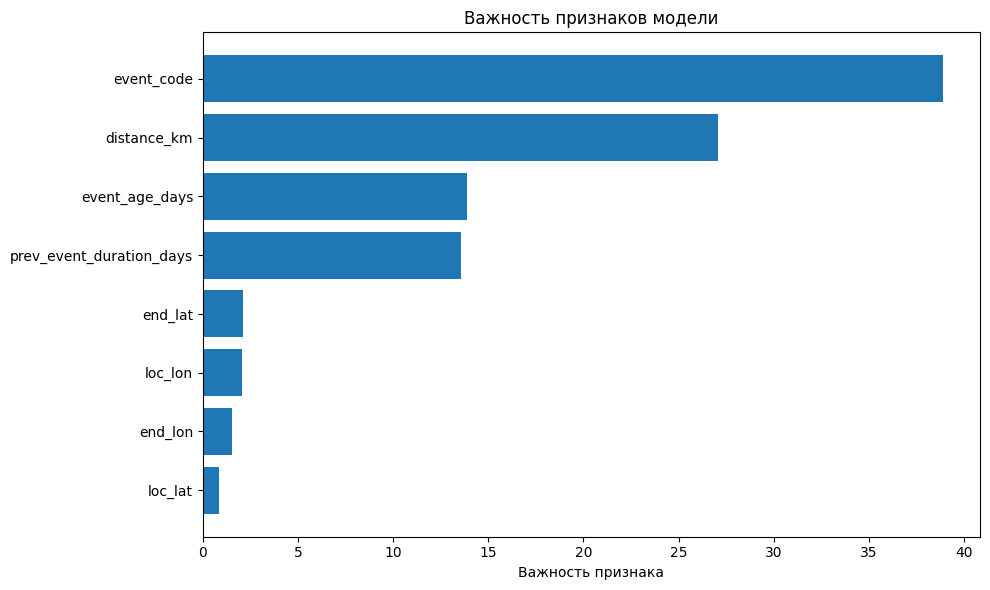


Важность признаков:
                    feature  importance
6                event_code   38.895565
4               distance_km   27.073958
7            event_age_days   13.893331
5  prev_event_duration_days   13.575627
2                   end_lat    2.115211
1                   loc_lon    2.046327
3                   end_lon    1.529525
0                   loc_lat    0.870455


In [23]:


# Получаем важность признаков
feature_importance = best_model.get_feature_importance()
feature_names = X_train.columns

# Создаем DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Строим график
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Важность признака')
plt.title('Важность признаков модели')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nВажность признаков:")
print(importance_df)


### Добавления фич

Попробуем просчитать train-only статистики в срезе циклов по event_code

In [ ]:
df_expanded = df.copy()


# df_expanded: daily-датасет, обязательно содержит cycle_id, dt, event_code
df_expanded = df_expanded.sort_values(["dt", "cycle_id"])

# Разбиение на тренировочную, валидационную и тестовую выборку
n = len(df_expanded)

train_df = df_expanded.iloc[:int(n * 0.6)].copy()
val_df    = df_expanded.iloc[int(n * 0.6):int(n * 0.7)].copy()
test_df   = df_expanded.iloc[int(n * 0.7):].copy()

# Сегменты event_code внутри cycle_id
train_df = train_df.sort_values(["cycle_id", "dt"])
is_new_seg = (train_df["event_code"] != train_df["event_code"].shift(1)) | (train_df["cycle_id"] != train_df["cycle_id"].shift(1))
train_df["seg_id"] = is_new_seg.cumsum()

# Длительность сегмента (сколько дней подряд длится event_code)
seg_len = (
    train_df.groupby(["seg_id", "event_code"], as_index=False)
            .size()
            .rename(columns={"size": "seg_len_days"})
)

# Медиана длительности сегмента по event_code (train-only)
event_median = seg_len.groupby("event_code")["seg_len_days"].median()

# Маппим на train/test
for part in (train_df, val_df,test_df):
    part["event_median_duration_days"] = part["event_code"].map(event_median)

# Fallback для event_code, которых не было в train (редко, но бывает)
global_median = seg_len["seg_len_days"].median()
train_df["event_median_duration_days"] = train_df["event_median_duration_days"].fillna(global_median)
val_df["event_median_duration_days"] = val_df["event_median_duration_days"].fillna(global_median)
test_df["event_median_duration_days"]  = test_df["event_median_duration_days"].fillna(global_median)


In [18]:
train_df.head()

,dt,cnt_id,cycle_id,event,location_name,end_location_name,cnt_type,days_between_events,days_until_free,loc_lat,loc_lon,end_lat,end_lon,distance_km,event_code,event_age_days,days_since_last_event,prev_event_duration_days,seg_id,event_median_duration_days
0,2006-02-05,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,0,56,43.115068,131.885577,55.625578,37.606392,6423.45279,1,0,0,0,1,10.0
1,2006-02-06,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,0,55,43.115068,131.885577,55.625578,37.606392,6423.45279,1,1,1,0,1,10.0
2,2006-02-07,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,0,54,43.115068,131.885577,55.625578,37.606392,6423.45279,1,2,2,0,1,10.0
3,2006-02-08,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,0,53,43.115068,131.885577,55.625578,37.606392,6423.45279,1,3,3,0,1,10.0
4,2006-02-09,BUTU1300953,BUTU1300953_cycle_1,Передан_на_погрузку,Владивосток,Москва,40,0,52,43.115068,131.885577,55.625578,37.606392,6423.45279,1,4,4,0,1,10.0


In [29]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
import numpy as np

feature_cols = [
    "loc_lat","loc_lon","end_lat","end_lon","distance_km",
    "prev_event_duration_days",
    "event_code",
    "event_age_days",
    "event_median_duration_days",  # новая
    "days_until_free"
]

# Сортировка данных
train_df, val_df, test_df = train_df[feature_cols], val_df[feature_cols], test_df[feature_cols]




X_train = train_df.drop(columns=['days_until_free'])
y_train = train_df['days_until_free']

X_val = val_df.drop(columns=['days_until_free'])
y_val = val_df['days_until_free']

X_test = test_df.drop(columns=['days_until_free'])
y_test = test_df['days_until_free']


cat_features = ["event_code"]

# CatBoost Pools
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool   = Pool(X_val, y_val, cat_features=cat_features)
test_pool  = Pool(X_test, y_test, cat_features=cat_features)

# Optuna objective
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "loss_function": "RMSE",
        "random_state": 42,
        "verbose": 0
    }

    model = CatBoostRegressor(**params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=50,
        verbose=False
    )

    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    return rmse

# Запуск Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)

print("Best params:", study.best_params)
print("Best RMSE:", study.best_value)

# Обучение лучшей модели
best_model = CatBoostRegressor(
    **study.best_params,
    loss_function="RMSE",
    random_state=42,
    verbose=100
)

best_model.fit(train_pool, eval_set=val_pool)

# Оценка качества
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")





[I 2026-01-14 18:27:13,024] A new study created in memory with name: no-name-51ff2614-3520-4e1b-8163-15ae6507ce4b


[I 2026-01-14 18:27:20,950] Trial 0 finished with value: 9.109068809595536 and parameters: {'iterations': 717, 'learning_rate': 0.07877004638822564, 'depth': 4, 'l2_leaf_reg': 9.911745923233449}. Best is trial 0 with value: 9.109068809595536.
[I 2026-01-14 18:27:25,628] Trial 1 finished with value: 9.112691043035662 and parameters: {'iterations': 994, 'learning_rate': 0.09088892824016073, 'depth': 7, 'l2_leaf_reg': 8.649944385990759}. Best is trial 0 with value: 9.109068809595536.
[I 2026-01-14 18:27:34,733] Trial 2 finished with value: 9.100513519640703 and parameters: {'iterations': 465, 'learning_rate': 0.03381905722239308, 'depth': 9, 'l2_leaf_reg': 7.22042894961768}. Best is trial 2 with value: 9.100513519640703.
[I 2026-01-14 18:27:42,741] Trial 3 finished with value: 9.103892229256985 and parameters: {'iterations': 377, 'learning_rate': 0.04589234590199532, 'depth': 9, 'l2_leaf_reg': 4.097150541995738}. Best is trial 2 with value: 9.100513519640703.
[I 2026-01-14 18:27:50,107] T

Best params: {'iterations': 433, 'learning_rate': 0.031212739908111888, 'depth': 10, 'l2_leaf_reg': 9.766935656131485}
Best RMSE: 9.096903109917928
0:	learn: 13.8013324	test: 13.4775031	best: 13.4775031 (0)	total: 44.7ms	remaining: 19.3s
100:	learn: 9.0617776	test: 9.1081337	best: 9.1081337 (100)	total: 5.43s	remaining: 17.9s
200:	learn: 8.9938326	test: 9.1098827	best: 9.0969031 (120)	total: 10.8s	remaining: 12.4s
300:	learn: 8.9771183	test: 9.1148435	best: 9.0969031 (120)	total: 16.2s	remaining: 7.1s
400:	learn: 8.9605265	test: 9.1171347	best: 9.0969031 (120)	total: 21.8s	remaining: 1.74s
432:	learn: 8.9557124	test: 9.1185398	best: 9.0969031 (120)	total: 23.6s	remaining: 0us

bestTest = 9.09690311
bestIteration = 120

Shrink model to first 121 iterations.
Mean Squared Error (MSE): 81.2620
Root Mean Squared Error (RMSE): 9.0145
Mean Absolute Error (MAE): 7.0046
R² Score: 0.5770


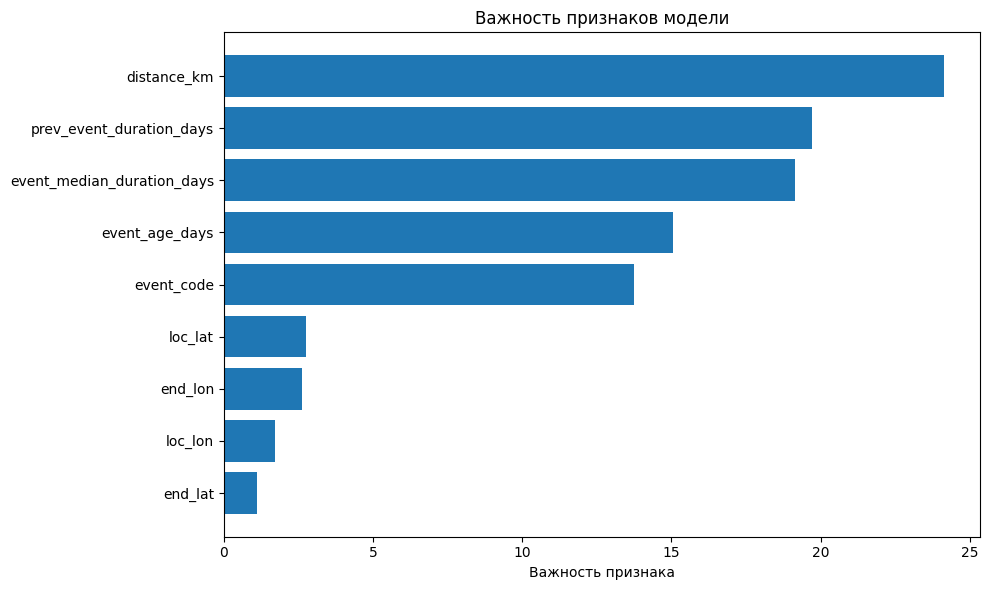


Важность признаков:
                      feature  importance
4                 distance_km   24.136356
5    prev_event_duration_days   19.706277
8  event_median_duration_days   19.152836
7              event_age_days   15.044322
6                  event_code   13.741509
0                     loc_lat    2.761752
3                     end_lon    2.615977
1                     loc_lon    1.723414
2                     end_lat    1.117556


In [30]:


# Получаем важность признаков
feature_importance = best_model.get_feature_importance()
feature_names = X_train.columns

# Создаем DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Строим график
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Важность признака')
plt.title('Важность признаков модели')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nВажность признаков:")
print(importance_df)


Теперь добавим еще одну фичу
* event_age_ratio

In [ ]:
df_expanded = df.copy(df)


# df_expanded: daily-датасет, обязательно содержит cycle_id, dt, event_code
df_expanded = df_expanded.sort_values(["dt", "cycle_id"])

# Разбиение на тренировочную, валидационную и тестовую выборку
n = len(df_expanded)

train_df = df_expanded.iloc[:int(n * 0.6)].copy()
val_df    = df_expanded.iloc[int(n * 0.6):int(n * 0.7)].copy()
test_df   = df_expanded.iloc[int(n * 0.7):].copy()

# Сегменты event_code внутри cycle_id
train_df = train_df.sort_values(["cycle_id", "dt"])
is_new_seg = (train_df["event_code"] != train_df["event_code"].shift(1)) | (train_df["cycle_id"] != train_df["cycle_id"].shift(1))
train_df["seg_id"] = is_new_seg.cumsum()

# Длительность сегмента (сколько дней подряд длится event_code)
seg_len = (
    train_df.groupby(["seg_id", "event_code"], as_index=False)
            .size()
            .rename(columns={"size": "seg_len_days"})
)

# Медиана длительности сегмента по event_code (train-only)
event_median = seg_len.groupby("event_code")["seg_len_days"].median()

# Маппим на train/test
for part in (train_df, val_df,test_df):
    part["event_median_duration_days"] = part["event_code"].map(event_median)

# Fallback для event_code, которых не было в train (редко, но бывает)
global_median = seg_len["seg_len_days"].median()
train_df["event_median_duration_days"] = train_df["event_median_duration_days"].fillna(global_median)
val_df["event_median_duration_days"] = val_df["event_median_duration_days"].fillna(global_median)
test_df["event_median_duration_days"]  = test_df["event_median_duration_days"].fillna(global_median)


In [46]:
feature_cols = [
    "loc_lat","loc_lon","end_lat","end_lon","distance_km",
    "prev_event_duration_days",
    "event_code",
    "event_age_days",
    "event_median_duration_days",  # новая
    "days_until_free"
]

# Сортировка данных
train_df, val_df, test_df = train_df[feature_cols], val_df[feature_cols], test_df[feature_cols]

train_df["event_age_over"] = (train_df['event_age_days'] - train_df['event_median_duration_days']).apply(lambda x: max(0,x))
val_df["event_age_over"] = (val_df['event_age_days'] - val_df['event_median_duration_days']).apply(lambda x: max(0,x))
test_df["event_age_over"] = (test_df['event_age_days'] - test_df['event_median_duration_days']).apply(lambda x: max(0,x))


X_train = train_df.drop(columns=['days_until_free'])
y_train = train_df['days_until_free']

X_val = val_df.drop(columns=['days_until_free'])
y_val = val_df['days_until_free']

X_test = test_df.drop(columns=['days_until_free'])
y_test = test_df['days_until_free']


cat_features = ["event_code"]

# CatBoost Pools
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool   = Pool(X_val, y_val, cat_features=cat_features)
test_pool  = Pool(X_test, y_test, cat_features=cat_features)

# Optuna objective
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "loss_function": "RMSE",
        "random_state": 42,
        "verbose": 0
    }

    model = CatBoostRegressor(**params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=50,
        verbose=False
    )

    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    return rmse

# Запуск Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)

print("Best params:", study.best_params)
print("Best RMSE:", study.best_value)

# Обучение лучшей модели
best_model = CatBoostRegressor(
    **study.best_params,
    loss_function="RMSE",
    random_state=42,
    verbose=100
)

best_model.fit(train_pool, eval_set=val_pool)

# Оценка качества
y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mask = y_test > 20
mae_long = mean_absolute_error(y_test[mask], y_pred[mask])


print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAE для длинных сроков: {mae_long:.4f}")

pd.DataFrame({
    "event": X_test["event_code"],
    "err": (y_pred - y_test).abs()
}).groupby("event").mean()



[I 2026-01-14 22:45:58,083] A new study created in memory with name: no-name-ef98c129-900e-40fd-8daf-6fecb839fc41
[I 2026-01-14 22:46:03,948] Trial 0 finished with value: 9.1054502104243 and parameters: {'iterations': 889, 'learning_rate': 0.08289125728989678, 'depth': 10, 'l2_leaf_reg': 3.7287119148257357}. Best is trial 0 with value: 9.1054502104243.
[I 2026-01-14 22:46:11,128] Trial 1 finished with value: 9.116410159637311 and parameters: {'iterations': 841, 'learning_rate': 0.029064631250071936, 'depth': 6, 'l2_leaf_reg': 8.19646863434777}. Best is trial 0 with value: 9.1054502104243.
[I 2026-01-14 22:46:16,316] Trial 2 finished with value: 9.105094821293626 and parameters: {'iterations': 639, 'learning_rate': 0.0685045530001162, 'depth': 9, 'l2_leaf_reg': 6.582425151071146}. Best is trial 2 with value: 9.105094821293626.
[I 2026-01-14 22:46:24,587] Trial 3 finished with value: 9.115830951730878 and parameters: {'iterations': 987, 'learning_rate': 0.06797824662201267, 'depth': 7, '

Best params: {'iterations': 962, 'learning_rate': 0.059687991171843376, 'depth': 10, 'l2_leaf_reg': 7.620262291867948}
Best RMSE: 9.099010958233498
0:	learn: 13.5857342	test: 13.2712467	best: 13.2712467 (0)	total: 59.5ms	remaining: 57.2s
100:	learn: 8.9893841	test: 9.1104798	best: 9.0990110 (57)	total: 4.73s	remaining: 40.3s
200:	learn: 8.9518201	test: 9.1216347	best: 9.0990110 (57)	total: 9.19s	remaining: 34.8s
300:	learn: 8.9279964	test: 9.1223700	best: 9.0990110 (57)	total: 14s	remaining: 30.7s
400:	learn: 8.9057443	test: 9.1270268	best: 9.0990110 (57)	total: 19s	remaining: 26.6s
500:	learn: 8.8848744	test: 9.1274528	best: 9.0990110 (57)	total: 24s	remaining: 22.1s
600:	learn: 8.8668639	test: 9.1300662	best: 9.0990110 (57)	total: 29.2s	remaining: 17.6s
700:	learn: 8.8504563	test: 9.1274680	best: 9.0990110 (57)	total: 34.5s	remaining: 12.9s
800:	learn: 8.8374271	test: 9.1283734	best: 9.0990110 (57)	total: 40s	remaining: 8.05s
900:	learn: 8.8223751	test: 9.1312238	best: 9.0990110 (57)

,err
event,
1,8.989411
2,8.151133
3,7.964962
4,7.281579
5,5.531206
6,1.171865


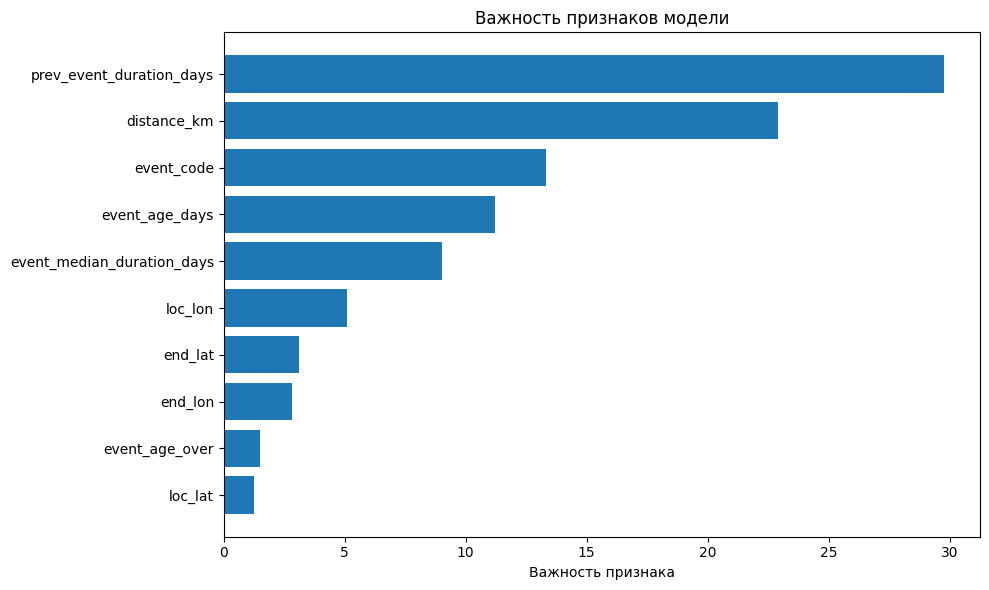


Важность признаков:
                      feature  importance
5    prev_event_duration_days   29.770192
4                 distance_km   22.927655
6                  event_code   13.332506
7              event_age_days   11.204660
8  event_median_duration_days    9.001062
1                     loc_lon    5.072676
2                     end_lat    3.119843
3                     end_lon    2.815718
9              event_age_over    1.509008
0                     loc_lat    1.246679


In [47]:


# Получаем важность признаков
feature_importance = best_model.get_feature_importance()
feature_names = X_train.columns

# Создаем DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Строим график
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Важность признака')
plt.title('Важность признаков модели')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nВажность признаков:")
print(importance_df)
